In [1]:

%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install faiss-gpu

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Unsloth

In [3]:
from unsloth import FastSentenceTransformer

fourbit_models = [
    "unsloth/all-MiniLM-L6-v2",
    "unsloth/embeddinggemma-300m",
    "unsloth/Qwen3-Embedding-4B",
    "unsloth/Qwen3-Embedding-0.6B",
    "unsloth/all-mpnet-base-v2",
    "unsloth/gte-modernbert-base",
    "unsloth/bge-m3",
    "unsloth/snowflake-arctic-embed-l-v2.0"

] # More models at https://huggingface.co/unsloth

model = FastSentenceTransformer.from_pretrained(
    model_name = "unsloth/snowflake-arctic-embed-l-v2.0",
    max_seq_length = 512,   # Choose any for long context!
    full_finetuning = False, # [NEW!] We have full finetuning now!
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

Unsloth: Using fast encoder path for xlm-roberta (torch.compile + SDPA)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

We now add LoRA adapters so we only need to update a small amount of parameters!

In [4]:
model = FastSentenceTransformer.get_peft_model(
    model,
    r = 64, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ['value', 'key', 'dense', 'query'],
    lora_alpha = 128,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = True, # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    task_type = "FEATURE_EXTRACTION"
)

Unsloth: Enabled gradient checkpointing
Unsloth: torch.compile will be applied automatically if max_steps > 240


<a name="Data"></a>
### Data Prep
We now use the `sentence-transformers/all-nli` dataset. This dataset provides a massive corpus of sentence pairs labeled for entailment, neutral, or contradiction. It is widely used to fine-tune models for generating semantically meaningful sentence embeddings.

In [5]:
import json
import re
import pandas as pd

# SQuAD formatındaki JSON'u pandas DataFrame'e çeviriyoruz
file_path = "/content/drive/MyDrive/embedings/squad_dataset.json"

with open(file_path, "r", encoding="utf-8") as f:
    squad_json = json.load(f)

records = []
data_list = squad_json.get('data', [])
if isinstance(data_list, dict):
    data_list = [data_list]

for item in data_list:
    for para in item.get('paragraphs', []):
        context = para.get('context', '')
        for qa in para.get('qas', []):
            question = qa.get('question', '')
            if question and context:
                records.append({'question': question, 'context': context})

train_df = pd.DataFrame(records)

# Metin ön-işleme: küçük harf, URL temizliği, boşluk/noktalama normalleştirme
def preprocess_text(x):
    x = x.lower()
    x = re.sub(r"http\S+", '', x)
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"\.+", ".", x)
    x = re.sub(r"\,+", ",", x)
    return x.strip()

train_df['question'] = train_df['question'].apply(preprocess_text)
train_df['context']  = train_df['context'].apply(preprocess_text)

print(f"Toplam QA çifti  : {len(train_df)}")
print(f"Benzersiz bağlam : {train_df['context'].nunique()}")
train_df.head(3)

Toplam QA çifti  : 7194
Benzersiz bağlam : 1059


,question,context
0,what is the primary objective of the study men...,perceptions of artiﬁcial intelligence among he...
1,how was the survey distributed?,perceptions of artiﬁcial intelligence among he...
2,who were the participants in the survey?,perceptions of artiﬁcial intelligence among he...


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  0%|          | 0/7194 [00:00<?, ?it/s]

  0%|          | 0/7194 [00:00<?, ?it/s]

Question — mean:15  p90:20  p95:22  max:38
Context  — mean:257  p90:316  p95:351  max:963

→ QUERY_MAX_LEN   = 32
→ PASSAGE_MAX_LEN = 352


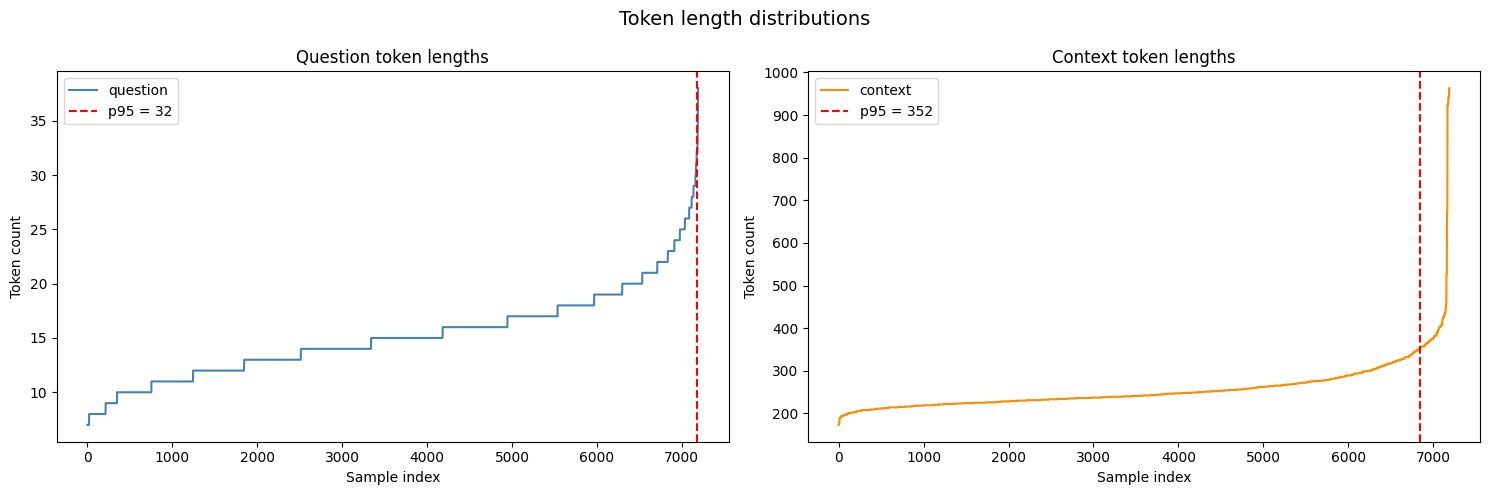

In [6]:
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

tqdm.pandas()

# Token uzunluk dağılımı — p95'e göre optimum max_length seçimi
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

question_lens = train_df['question'].progress_apply(lambda x: len(tokenizer(x)['input_ids']))
context_lens  = train_df['context'].progress_apply(lambda x: len(tokenizer(x)['input_ids']))

def round_to_32(n):
    return int(((n + 31) // 32) * 32)

# MiniLM-L6-v2 modelinin tokenizer max_length'i 512, bu sınırda kalıyoruz
QUERY_MAX_LEN   = min(round_to_32(int(question_lens.quantile(0.95))), 512)
PASSAGE_MAX_LEN = min(round_to_32(int(context_lens.quantile(0.95))),  512)

print(f"Question — mean:{question_lens.mean():.0f}  p90:{question_lens.quantile(0.90):.0f}  p95:{question_lens.quantile(0.95):.0f}  max:{question_lens.max()}")
print(f"Context  — mean:{context_lens.mean():.0f}  p90:{context_lens.quantile(0.90):.0f}  p95:{context_lens.quantile(0.95):.0f}  max:{context_lens.max()}")
print(f"\n→ QUERY_MAX_LEN   = {QUERY_MAX_LEN}")
print(f"→ PASSAGE_MAX_LEN = {PASSAGE_MAX_LEN}")

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle('Token length distributions', fontsize=14)

question_lens.sort_values().reset_index(drop=True).plot.line(ax=ax1, color='steelblue')
ax1.axvline(x=(question_lens <= QUERY_MAX_LEN).sum(), color='red', linestyle='--', label=f'p95 = {QUERY_MAX_LEN}')
ax1.set_title('Question token lengths')
ax1.set_xlabel('Sample index'); ax1.set_ylabel('Token count'); ax1.legend()

context_lens.sort_values().reset_index(drop=True).plot.line(ax=ax2, color='darkorange')
ax2.axvline(x=(context_lens <= PASSAGE_MAX_LEN).sum(), color='red', linestyle='--', label=f'p95 = {PASSAGE_MAX_LEN}')
ax2.set_title('Context token lengths')
ax2.set_xlabel('Sample index'); ax2.set_ylabel('Token count'); ax2.legend()

plt.tight_layout()
plt.show()

In [7]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 133.4 MB/s eta 0:00:00


In [8]:


import gc
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer


gc.collect()
torch.cuda.empty_cache()

# Hard Negative Mining — base embedding modeli ile benzer ama yanlış bağlamlar aranır
mining_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
mining_model.max_seq_length = max(QUERY_MAX_LEN, PASSAGE_MAX_LEN)

# Aday havuz = benzersiz bağlamlar
unique_contexts = train_df['context'].drop_duplicates().tolist()
print(f"Aday havuz: {len(unique_contexts)} benzersiz bağlam")

print("Adaylar kodlaniyor...")
cand_embs = mining_model.encode(unique_contexts, normalize_embeddings=True,
                                show_progress_bar=True, batch_size=64,
                                convert_to_numpy=True)

print("Sorular kodlaniyor...")
query_texts = train_df['question'].tolist()
query_embs = mining_model.encode(query_texts, normalize_embeddings=True,
                                 show_progress_bar=True, batch_size=64,
                                 convert_to_numpy=True)

del mining_model
gc.collect()
torch.cuda.empty_cache()

# FAISS inner-product indeks (vektörler normalize, dolayısıyla IP = cosine sim)
index = faiss.IndexFlatIP(cand_embs.shape[1])
index.add(cand_embs.astype('float32'))

_, nn_indices = index.search(query_embs.astype('float32'), 100)

RANGE_START, RANGE_END = 10, 100   # Top-10'u atla (çok benzer → false negative riski)
np.random.seed(3407)

positives = train_df['context'].tolist()
negatives = []
for i, pos_ctx in enumerate(positives):
    pool = [unique_contexts[j] for j in nn_indices[i][RANGE_START:RANGE_END]
            if unique_contexts[j] != pos_ctx]
    negatives.append(np.random.choice(pool) if pool else pos_ctx)

train_df['negative'] = negatives

del index, cand_embs, query_embs
gc.collect()
torch.cuda.empty_cache()

print(f"\nHard negatives eklendi. Örnek satır:")
print(train_df.iloc[0][['question', 'negative']].to_dict())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Aday havuz: 1059 benzersiz bağlam
Adaylar kodlaniyor...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Sorular kodlaniyor...


Batches:   0%|          | 0/113 [00:00<?, ?it/s]


Hard negatives eklendi. Örnek satır:
{'question': 'what is the primary objective of the study mentioned in the text?', 'negative': np.str_('44. tajirian t, stergiopoulos v, strudwick g, sequeira l, sanches m, kemp j, ramamoorthi k, zhang t, jankowicz d. the influ\xad ence of electronic health record use on physician burnout: cross- sectional survey. j med internet res. 2020;22(7). doi: \u200bh\u200bt\u200bt\u200bp\u200bs\u200b:\u200b/\u200b/\u200bd\u200bo\u200bi\u200b.\u200b o\u200br\u200bg\u200b/\u200b1\u200b0\u200b.\u200b2\u200b1\u200b9\u200b6\u200b/\u200b1\u200b9\u200b2\u200b7\u200b4\u200b.\u200b 45. medcentral. (n.d.). ai scribes: helpful tools or additional bur\xad den? available from: \u200bh\u200bt\u200bt\u200bp\u200bs\u200b:\u200b/\u200b/\u200bw\u200bw\u200bw\u200b.\u200bm\u200be\u200bd\u200bc\u200be\u200bn\u200bt\u200br\u200ba\u200bl\u200b.\u200bc\u200bo\u200bm\u200b/\u200ba\u200bi\u200b/\u200ba\u200bi\u200b-\u200bs\u200bc\u200br\u200bi\u200bb\u200be\u200bs\u200b-\u200bh\u200

In [9]:
from datasets import Dataset

# (anchor, positive, negative) formatında HF Dataset — MultipleNegativesRankingLoss
# bu üçlü yapıda hard negative + in-batch negatives'i birlikte kullanır
dataset = Dataset.from_pandas(
    train_df.rename(columns={'question': 'anchor', 'context': 'positive'})
            [['anchor', 'positive', 'negative']]
)
print(f"Eğitim veri seti: {len(dataset)} örnek")
print(dataset)

Eğitim veri seti: 7194 örnek
Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 7194
})


Let's take a look at the dataset structure:

In [10]:
print("Dataset examples:")
for i in range(6):
    print(dataset[i])

Dataset examples:
{'anchor': 'what is the primary objective of the study mentioned in the text?', 'positive': 'perceptions of artiﬁcial intelligence among healthcare staff: a qualitative survey study simone castagno* and mohamed khalifa department of interventional radiology, royal free hospital, london, united kingdom objectives: the medical community is in agreement that artiﬁcial intelligence (ai) will have a radical impact on patient care in the near future. the purpose of this study is to assess the awareness of ai technologies among health professionals and to investigate their perceptions toward ai applications in medicine. design: a web-based google forms survey was distributed via the royal free london nhs foundation trust e-newsletter. setting: only staff working at the nhs foundation trust received an invitation to complete the online questionnaire. participants: 98 healthcare professionals out of 7,538 (response rate 1.3%; ci 95%; margin of error 9.64%) completed the survey

## Baseline Inference
Let's test the base model before fine-tuning to see how it performs on our specific domain.

In [11]:
from sentence_transformers import util

def test_inference(model, run_name = "Run"):
    """Test model with a query and candidate sentences"""

    query = "A soccer player in a blue jersey is running across the field."

    candidates = [
        "An athlete is practicing a sport outdoors.",  # Correct - entailment
        "The player is about to score a goal for his team.",  # Neutral - possible but uncertain
        "A person is sitting quietly on the grass.",  # Wrong - contradicts action
        "Jersey is a knit fabric used predominantly for clothing manufacture.",  # Wrong - unrelated definition
    ]

    query_emb = model.encode(query, convert_to_tensor = True)
    candidate_embs = model.encode(candidates, convert_to_tensor = True)
    scores = util.cos_sim(query_emb, candidate_embs)[0]

    results = []
    for i, score in enumerate(scores):
        results.append((candidates[i], score.item()))
    results.sort(key = lambda x: x[1], reverse = True)

    print(f"\n--- {run_name} Results for query: '{query}' ---")
    for text, score in results:
        print(f"{score:.4f} | {text}")

test_inference(model, run_name = "Pre-Training")


--- Pre-Training Results for query: 'A soccer player in a blue jersey is running across the field.' ---
0.6172 | The player is about to score a goal for his team.
0.4746 | A person is sitting quietly on the grass.
0.4668 | An athlete is practicing a sport outdoors.
0.3301 | Jersey is a knit fabric used predominantly for clothing manufacture.


<a name="Train"></a>
### Train the model
Now let's train our model. We use `MultipleNegativesRankingLoss`

 This loss function uses other positives in the same batch as negative examples, which is efficient for contrastive learning.

In [12]:
from sentence_transformers import (
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    losses
)
from sentence_transformers.training_args import BatchSamplers
from unsloth import is_bf16_supported
from transformers import TrainerCallback

# Loss'u in-memory loglayan callback (trainer_state.json'a güvenmiyoruz)
loss_log = []
class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            loss_log.append({'step': state.global_step, 'loss': logs['loss']})

# MultipleNegativesRankingLoss — (anchor, positive, negative) üçlüsü +
# aynı batch içindeki diğer positive'leri de negatif olarak kullanır
loss = losses.MultipleNegativesRankingLoss(model)

trainer = SentenceTransformerTrainer(
    model = model,
    train_dataset = dataset,
    loss = loss,
    args = SentenceTransformerTrainingArguments(
        output_dir = "/content/drive/MyDrive/embedings/all_mini_l6_v2",
        num_train_epochs = 3,
        per_device_train_batch_size = 256,
        gradient_accumulation_steps = 1,
        learning_rate = 2e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 5,
        warmup_ratio = 0.03,
        report_to = "none",
        lr_scheduler_type = 'linear',
        # Anchor'lar arasında tekrar olabileceği için dupe'ları aynı batch'e koyma
        batch_sampler = BatchSamplers.NO_DUPLICATES,
    ),
    callbacks = [LossLogger()],
)

/tmp/ipykernel_17537/3881842984.py:1: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (
/tmp/ipykernel_17537/3881842984.py:6: DeprecationWarning: Importing from 'sentence_transformers.training_args' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.training_args' instead.
  from sentence_transformers.training_args import BatchSamplers


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [13]:
# @title Show current memory stats
import torch
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA RTX PRO 6000 Blackwell Server Edition. Max memory = 94.971 GB.
1.809 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [14]:
trainer_stats = trainer.train()

Step,Training Loss
5,3.137100
10,2.284000
15,2.029700
20,2.018800
25,1.847800
30,1.520200
35,1.596800
40,1.445500
45,1.499800
50,1.498200


In [15]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

601.918 seconds used for training.
10.03 minutes used for training.
Peak reserved memory = 49.842 GB.
Peak reserved memory for training = 48.033 GB.
Peak reserved memory % of max memory = 52.481 %.
Peak reserved memory for training % of max memory = 50.576 %.


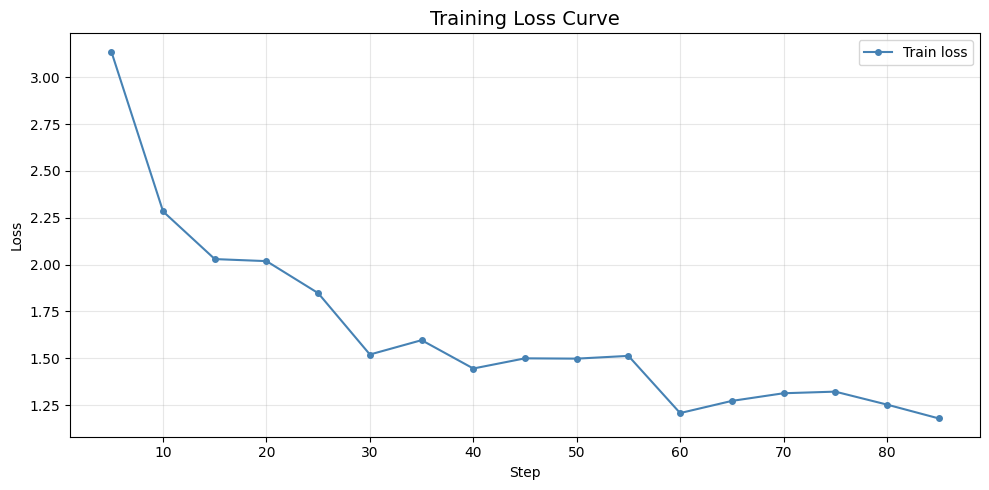

İlk loss    : 3.1371
Son loss    : 1.1792
En iyi loss : 1.1792  (step 85)
Toplam log  : 17 adım


In [16]:
# @title Training Loss Curve
import matplotlib.pyplot as plt

if loss_log:
    steps       = [e['step'] for e in loss_log]
    losses_vals = [e['loss'] for e in loss_log]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, losses_vals, marker='o', markersize=4, linewidth=1.5,
            color='steelblue', label='Train loss')
    ax.set_title('Training Loss Curve', fontsize=14)
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.show()

    best_step = steps[losses_vals.index(min(losses_vals))]
    print(f"İlk loss    : {losses_vals[0]:.4f}")
    print(f"Son loss    : {losses_vals[-1]:.4f}")
    print(f"En iyi loss : {min(losses_vals):.4f}  (step {best_step})")
    print(f"Toplam log  : {len(losses_vals)} adım")
else:
    print("loss_log boş — LossLogger callback'i çalışmamış olabilir.")

<a name="Inference"></a>
### Inference
Let's run the model after training to see the improvements!

In [17]:
test_inference(model, run_name = "Post-Training")


--- Post-Training Results for query: 'A soccer player in a blue jersey is running across the field.' ---
0.5469 | The player is about to score a goal for his team.
0.4390 | A person is sitting quietly on the grass.
0.4292 | An athlete is practicing a sport outdoors.
0.3480 | Jersey is a knit fabric used predominantly for clothing manufacture.


## Quantitative Evaluation — Base vs Fine-tuned

Fine-tune edilmiş modeli, temel `sentence-transformers/all-MiniLM-L6-v2` ile iki standart retrieval metriği üzerinden karşılaştırıyoruz:

1. **Similarity Distribution** — doğru (pozitif) ve rastgele (negatif) çiftlerin cosine similarity dağılımları. İyi bir fine-tune pozitif dağılımı yüksek, negatif dağılımı düşük tutarak iki dağılımı birbirinden uzaklaştırır.
2. **Recall@k** — her soru için doğru bağlamın top-k sonuç içinde yer alma oranı (k = 1, 3, 5, 10, 20). Makalelerde kullanılan standart retrieval metriğidir.

Base modeli yükleniyor...
Base embeddings...
Fine-tuned embeddings...

Base       — pos: 0.4071 ± 0.2057  |  neg: 0.2095 ± 0.1575  |  Δ=0.1976
Fine-tuned — pos: 0.4207 ± 0.1162  |  neg: 0.0057 ± 0.0897  |  Δ=0.4150


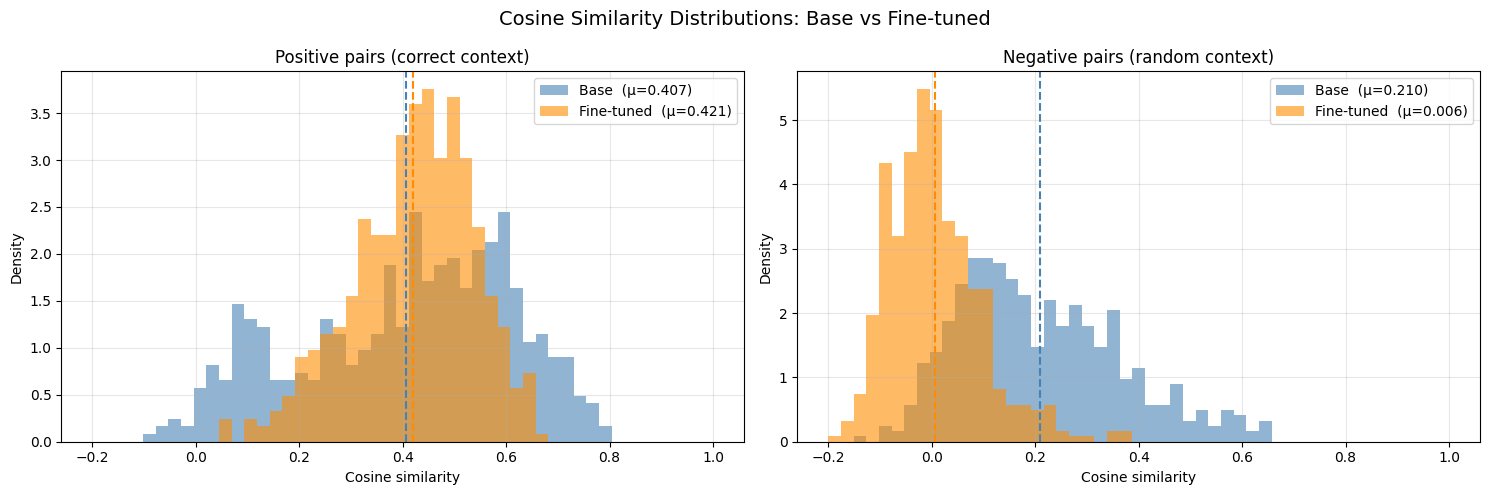

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
EVAL_SAMPLE = 500

# Değerlendirme örneklemi
eval_df = train_df.sample(EVAL_SAMPLE, random_state=42).reset_index(drop=True)
eval_questions = eval_df['question'].tolist()
eval_contexts  = eval_df['context'].tolist()

# Base (fine-tune edilmemiş) modeli ayrı yükle — karşılaştırma için
print("Base modeli yükleniyor...")
base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
base_model.max_seq_length = max(QUERY_MAX_LEN, PASSAGE_MAX_LEN)

def encode_batched(st_model, texts, batch_size=64):
    return st_model.encode(texts, normalize_embeddings=True,
                           convert_to_tensor=True, batch_size=batch_size,
                           show_progress_bar=False, device=device).cpu()

print("Base embeddings...")
base_q = encode_batched(base_model, eval_questions)
base_c = encode_batched(base_model, eval_contexts)

print("Fine-tuned embeddings...")
ft_q = encode_batched(model, eval_questions)
ft_c = encode_batched(model, eval_contexts)

# Pozitif cosine sim (doğru eşleşme — diagonal)
base_pos = (base_q * base_c).sum(dim=1).numpy()
ft_pos   = (ft_q   * ft_c).sum(dim=1).numpy()

# Negatif cosine sim (rastgele karıştırılmış eşleşme)
rng = np.random.default_rng(42)
shuffle_idx = rng.permutation(len(eval_questions))
base_neg = (base_q * base_c[shuffle_idx]).sum(dim=1).numpy()
ft_neg   = (ft_q   * ft_c[shuffle_idx]).sum(dim=1).numpy()

print(f"\nBase       — pos: {base_pos.mean():.4f} ± {base_pos.std():.4f}  |  neg: {base_neg.mean():.4f} ± {base_neg.std():.4f}  |  Δ={base_pos.mean()-base_neg.mean():.4f}")
print(f"Fine-tuned — pos: {ft_pos.mean():.4f} ± {ft_pos.std():.4f}  |  neg: {ft_neg.mean():.4f} ± {ft_neg.std():.4f}  |  Δ={ft_pos.mean()-ft_neg.mean():.4f}")

# Histogram — base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Cosine Similarity Distributions: Base vs Fine-tuned', fontsize=14)

bins = np.linspace(-0.2, 1.0, 50)
for ax, (b, f, label) in zip(axes, [
    (base_pos, ft_pos, 'Positive pairs (correct context)'),
    (base_neg, ft_neg, 'Negative pairs (random context)')
]):
    ax.hist(b, bins=bins, alpha=0.6, color='steelblue',  label=f'Base  (μ={b.mean():.3f})', density=True)
    ax.hist(f, bins=bins, alpha=0.6, color='darkorange', label=f'Fine-tuned  (μ={f.mean():.3f})', density=True)
    ax.axvline(b.mean(), color='steelblue',  linestyle='--', linewidth=1.5)
    ax.axvline(f.mean(), color='darkorange', linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel('Cosine similarity'); ax.set_ylabel('Density')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Değerlendirme corpus'u: 409 benzersiz bağlam
Corpus kodlaniyor (base)...
Corpus kodlaniyor (fine-tuned)...

k            Base   Fine-tuned        Δ
--------------------------------------
@1          0.370        0.778   +0.408
@3          0.468        0.854   +0.386
@5          0.522        0.888   +0.366
@10         0.584        0.924   +0.340
@20         0.646        0.960   +0.314


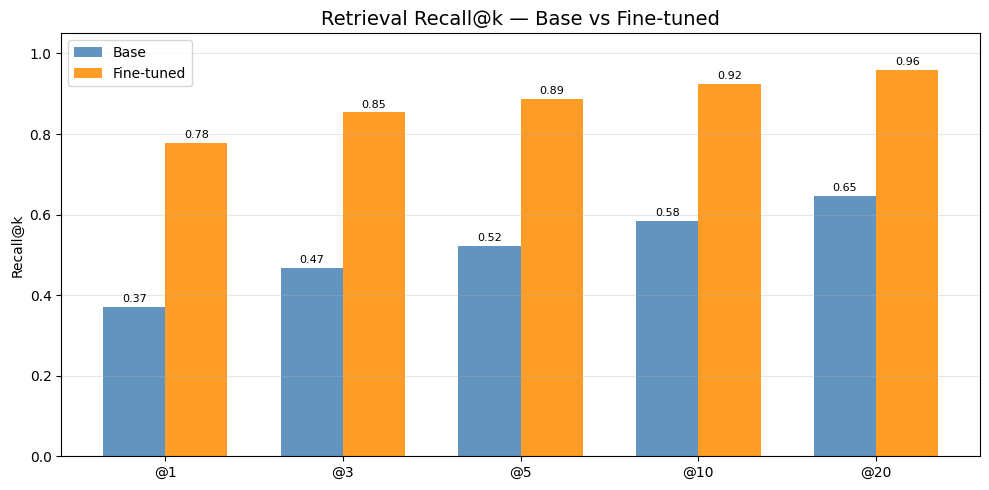

In [19]:
# Recall@k — her soru için doğru bağlamın top-k'ya düşme oranı
K_VALUES = [1, 3, 5, 10, 20]

corpus_texts = eval_df['context'].unique().tolist()
corpus_map   = {ctx: i for i, ctx in enumerate(corpus_texts)}
print(f"Değerlendirme corpus'u: {len(corpus_texts)} benzersiz bağlam")

print("Corpus kodlaniyor (base)...")
base_corpus = encode_batched(base_model, corpus_texts)
print("Corpus kodlaniyor (fine-tuned)...")
ft_corpus   = encode_batched(model, corpus_texts)

def recall_at_k(q_embs, c_embs, correct_idx, k_values):
    scores  = q_embs @ c_embs.T
    results = {}
    for k in k_values:
        top_k = scores.topk(k, dim=1).indices.numpy()
        hits  = sum(correct_idx[i] in top_k[i] for i in range(len(correct_idx)))
        results[k] = hits / len(correct_idx)
    return results

correct_idx = [corpus_map[c] for c in eval_df['context'].tolist()]
base_recall = recall_at_k(base_q, base_corpus, correct_idx, K_VALUES)
ft_recall   = recall_at_k(ft_q,   ft_corpus,   correct_idx, K_VALUES)

print(f"\n{'k':<6} {'Base':>10} {'Fine-tuned':>12} {'Δ':>8}")
print('-' * 38)
for k in K_VALUES:
    delta = ft_recall[k] - base_recall[k]
    print(f"@{k:<5} {base_recall[k]:>10.3f} {ft_recall[k]:>12.3f} {delta:>+8.3f}")

# Bar chart
x = np.arange(len(K_VALUES)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, [base_recall[k] for k in K_VALUES], w,
            label='Base', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, [ft_recall[k]   for k in K_VALUES], w,
            label='Fine-tuned', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'@{k}' for k in K_VALUES])
ax.set_ylabel('Recall@k')
ax.set_title('Retrieval Recall@k — Base vs Fine-tuned', fontsize=14)
ax.legend(); ax.set_ylim(0, 1.05)
ax.bar_label(b1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.2f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit, scroll down!

In [20]:
model.save_pretrained("/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0")  # Local saving
model.tokenizer.save_pretrained("/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0")
# model.push_to_hub("your_name/snowflake-arctic-embed-l-v2.0", token = "YOUR_HF_TOKEN") # Online saving
# model.tokenizer.push_to_hub("your_name/snowflake-arctic-embed-l-v2.0", token = "YOUR_HF_TOKEN") # Online saving

('/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0/tokenizer_config.json',
 '/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0/special_tokens_map.json',
 '/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0/sentencepiece.bpe.model',
 '/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0/added_tokens.json',
 '/content/drive/MyDrive/embedings/snowflake-arctic-embed-l-v2.0/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [21]:
if False:
    from unsloth import FastSentenceTransformer
    model = FastSentenceTransformer.from_pretrained(
        "model",
        # for_inference = True
    )

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [22]:
# Merge to 16bit
if False:
    model.save_pretrained_merged("all_minilm_l6_v2_finetune_16bit", tokenizer = model.tokenizer, save_method = "merged_16bit",)
if False: # Pushing to HF Hub
    model.push_to_hub_merged("HF_USERNAME/all_minilm_l6_v2_finetune_16bit", tokenizer = model.tokenizer, save_method = "merged_16bit", token = "YOUR_HF_TOKEN")

# Just LoRA adapters
if False:
    model.save_pretrained("all_minilm_l6_v2_lora")
if False: # Pushing to HF Hub
    model.push_to_hub("HF_USERNAME/all_minilm_l6_v2_lora", token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [docs page](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

In [23]:
# Save to 8bit Q8_0
if False:
    model.save_pretrained_gguf("all_minilm_l6_v2_finetune",)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False:
    model.push_to_hub_gguf("HF_USERNAME/all_minilm_l6_v2_finetune", token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False:
    model.save_pretrained_gguf("all_minilm_l6_v2_finetune", quantization_method = "f16")
if False: # Pushing to HF Hub
    model.push_to_hub_gguf("HF_USERNAME/all_minilm_l6_v2_finetune", quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False:
    model.save_pretrained_gguf("all_minilm_l6_v2_finetune", quantization_method = "q4_k_m")
if False: # Pushing to HF Hub
    model.push_to_hub_gguf("HF_USERNAME/all_minilm_l6_v2_finetune", quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/all_minilm_l6_v2_finetune", # Change hf to your username!
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN", # Get a token at https://huggingface.co/settings/tokens
    )

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  <b>This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)</b>
</div>